# 01 — Environment & Baselines

This notebook sanity-checks the 2048 environment (Game2048Env) and runs the two baselines that anchor the comparison: a **uniform-random** policy and a **greedy heuristic** policy. Both will later be compared against DQN (Notebook 02) and the N-tuple TD agent (Notebook 03).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, EVAL_DIR, LOG_DIR
from src.env import Game2048Env, ACTION_NAMES
from src.agents.random_agent import RandomAgent
from src.agents.greedy_agent import GreedyAgent
from src.eval.evaluate import run_eval, save_eval

set_seed(42)
sns.set_theme()
plt.rcParams['figure.dpi'] = 110
RNG = np.random.default_rng(42)

## 1. Env demo
Reset the env and step a few legal moves. The board is a (4, 4) `int8` of log2 values; `2**v` gives the displayed tile.

In [2]:
env = Game2048Env(seed=0)
board = env.reset(seed=0)
print('initial board:')
print(env.render('ansi'))
print('legal:', env.legal_actions(), '\n')
for _ in range(5):
    legal = env.legal_actions()
    a = int(RNG.choice(np.flatnonzero(legal)))
    board, r, done, info = env.step(a)
    print(f'action={ACTION_NAMES[a]:5s} r={r:3.0f} score={env.score:5d} done={done}')
    print(env.render('ansi'))
    print()

initial board:
    0     0     0     0
    0     0     0     0
    0     2     0     0
    0     2     0     0
legal: [ True  True  True  True] 

action=UP    r=  2 score=    2 done=False
    0     4     2     0
    0     0     0     0
    0     0     0     0
    0     0     0     0

action=LEFT  r=  0 score=    2 done=False
    4     2     4     0
    0     0     0     0
    0     0     0     0
    0     0     0     0

action=DOWN  r=  0 score=    2 done=False
    0     0     0     0
    0     0     2     0
    0     0     0     0
    4     2     4     0

action=RIGHT r=  0 score=    2 done=False
    0     0     0     0
    0     0     0     2
    2     0     0     0
    0     4     2     4

action=RIGHT r=  0 score=    2 done=False
    0     0     0     0
    0     0     2     2
    0     0     0     2
    0     4     2     4



## 2. Random baseline
Uniform over legal moves. The expected score is ~1k; the variance is huge.

In [3]:
random_metrics = run_eval(RandomAgent(seed=0), n_games=300, seed=0)
save_eval(random_metrics, EVAL_DIR / 'eval_random.json')
random_metrics

{'agent': 'random',
 'n_games': 300,
 'mean_score': 296.99666666666667,
 'median_score': 291.0,
 'max_score': 733,
 'mean_max_tile': 108.16,
 'max_max_tile': 256,
 'pct_reaching': {'512': 0.0,
  '1024': 0.0,
  '2048': 0.0,
  '4096': 0.0,
  '8192': 0.0},
 'mean_steps': 118.81}

## 3. Greedy heuristic baseline
1-step lookahead with `reward + α·monotonicity + β·empty_cells + γ·corner_bonus`. No learning.

In [4]:
greedy_metrics = run_eval(GreedyAgent(seed=0), n_games=200, seed=0)
save_eval(greedy_metrics, EVAL_DIR / 'eval_greedy.json')
greedy_metrics

{'agent': 'greedy',
 'n_games': 200,
 'mean_score': 1295.06,
 'median_score': 1179.5,
 'max_score': 2929,
 'mean_max_tile': 456.64,
 'max_max_tile': 1024,
 'pct_reaching': {'512': 0.59,
  '1024': 0.105,
  '2048': 0.0,
  '4096': 0.0,
  '8192': 0.0},
 'mean_steps': 447.415}

## 4. Quick comparison plot

,agent,mean_score,mean_max_tile
0,random,296.996667,108.16
1,greedy,1295.060000,456.64


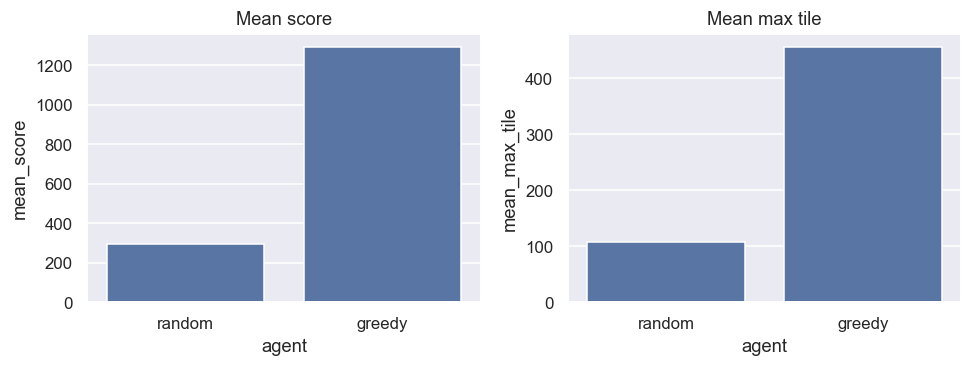

In [5]:
df = pd.DataFrame([
    {'agent': 'random', 'mean_score': random_metrics['mean_score'], 'mean_max_tile': random_metrics['mean_max_tile']},
    {'agent': 'greedy', 'mean_score': greedy_metrics['mean_score'], 'mean_max_tile': greedy_metrics['mean_max_tile']},
])
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.barplot(data=df, x='agent', y='mean_score', ax=axes[0]); axes[0].set_title('Mean score')
sns.barplot(data=df, x='agent', y='mean_max_tile', ax=axes[1]); axes[1].set_title('Mean max tile')
fig.tight_layout()
df

## Takeaway
- The random policy gives a noisy floor (~few hundred mean score).
- The greedy heuristic does considerably better even without learning, by avoiding moves that lose all empty squares or break monotonicity.
- Notebooks 02 (DQN) and 03 (N-tuple) train agents that should clear both bars; Notebook 04 puts everything side by side.